# Chương 2: Ví dụ minh họa tay – Thuật toán PrePost

**Thuật toán:** PrePost (Pre-Post order encoding + N-list)  
**Cấu trúc dữ liệu:** PPC-tree + N-list  
**Yêu cầu:** Minh họa từng bước hoàn toàn bằng tay (không dùng thư viện khai thác sẵn)

---
## Mục lục
1. [Ví dụ 1 – Cơ sở](#example1)
2. [Ví dụ 2 – Đặc biệt (single path)](#example2)
3. [Cross-check kết quả](#crosscheck)

---
## 0. Cài đặt thư viện hỗ trợ hiển thị

> **Mục đích:** Import các thư viện chuẩn của Python để hỗ trợ hiển thị kết quả và xử lý dữ liệu.  
> Không có thư viện khai thác tần số nào được dùng — toàn bộ logic thuật toán được tự cài đặt từ đầu.

| Thư viện | Vai trò |
|----------|---------|
| `os` | Đọc file từ đường dẫn tương đối |
| `itertools.combinations` | Sinh tổ hợp cho brute-force cross-check |
| `collections.defaultdict` | Đếm support item tiện lợi |
| `pandas` | Hiển thị bảng kết quả dễ đọc |

In [22]:
import os
from itertools import combinations
from collections import defaultdict
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print('Thư viện đã sẵn sàng')

Thư viện đã sẵn sàng


---
<a id='example1'></a>
## 1. Ví dụ 1 – Cơ sở

### 1.1 Cơ sở dữ liệu gốc

| TID | Giao dịch |
|-----|----------|
| T1  | 1, 2, 3  |
| T2  | 1, 3, 4  |
| T3  | 2, 3, 5  |
| T4  | 1, 2, 3, 5 |
| T5  | 2, 3, 4  |

**Tham số:** `minsup = 2` (tương đương 40% — ít nhất 2 trong 5 giao dịch phải chứa itemset)

> ** Bước tổng quát của PrePost:**
> 1. Xây dựng **PPC-tree** (Partial Pre-order Code tree) từ CSDL.
> 2. Từ PPC-tree, tạo **N-list** cho từng item phổ biến (1-itemset).
> 3. Duyệt đệ quy: giao N-list của hai itemset → N-list của itemset hợp; đếm support từ N-list.
> 4. Trả về tất cả itemset có support ≥ minsup.

**Tại sao PrePost hiệu quả?**  
Thay vì duyệt lại CSDL nhiều lần (như Apriori) hay xây conditional FP-tree (như FP-Growth),  
PrePost chỉ cần **giao hai danh sách số nguyên** để tính support — chi phí rất thấp.

In [23]:
# ── Đọc CSDL từ file (hoặc dùng trực tiếp nếu file chưa tồn tại)
DATA_PATH = os.path.join('..', 'data', 'toy', 'example_basic.txt')

def load_transactions(path):
    """Đọc file giao dịch; mỗi dòng là một giao dịch, các item cách nhau bởi dấu cách."""
    transactions = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                transactions.append(list(map(int, line.split())))
    return transactions

if os.path.exists(DATA_PATH):
    transactions = load_transactions(DATA_PATH)
else:
    # Dữ liệu mẫu nhúng thẳng (khớp với example_basic.txt)
    transactions = [
        [1, 2, 3],
        [1, 3, 4],
        [2, 3, 5],
        [1, 2, 3, 5],
        [2, 3, 4],
    ]
    print(' Không tìm thấy file, dùng dữ liệu nhúng sẵn.')

# Hiển thị bảng CSDL gốc
df_db = pd.DataFrame({
    'TID': [f'T{i+1}' for i in range(len(transactions))],
    'Giao dịch': [str(t) for t in transactions]
})
print('=== CSDL GỐC ===')
print(df_db.to_string(index=False))

=== CSDL GỐC ===
TID    Giao dịch
 T1    [1, 2, 3]
 T2    [1, 3, 4]
 T3    [2, 3, 5]
 T4 [1, 2, 3, 5]
 T5    [2, 3, 4]


### 1.2 Bước 1 – Tính support 1-itemset & xác định item phổ biến

PrePost dùng **thứ tự giảm dần theo support** để chèn vào PPC-tree (tương tự FP-tree).  
Item có support cao hơn được đặt gần gốc → chia sẻ prefix nhiều hơn → cây nhỏ hơn, N-list ngắn hơn.

**Công thức support của item `x`:**

$$\text{support}(x) = |\{T \in \mathcal{D} \mid x \in T\}|$$

**Kỳ vọng sau bước này:**
- Biết item nào vượt ngưỡng `minsup` → chỉ xử lý item phổ biến.
- Có `order_map` để sắp xếp mỗi giao dịch trước khi chèn vào cây.

> ️ **Tie-break:** Khi hai item có support bằng nhau, item có giá trị nhỏ hơn được ưu tiên để đảm bảo thứ tự xác định (deterministic).

In [24]:
MINSUP = 2

# Đếm support từng item
item_sup = defaultdict(int)
for t in transactions:
    for item in t:
        item_sup[item] += 1

# Lọc item phổ biến, sắp xếp giảm dần support (tie-break: item nhỏ hơn ưu tiên)
freq_items = sorted(
    [item for item, sup in item_sup.items() if sup >= MINSUP],
    key=lambda x: (-item_sup[x], x)
)
order_map = {item: idx for idx, item in enumerate(freq_items)}  # thứ tự chèn cây

print(f'minsup = {MINSUP}\n')
print('Support từng item:')
df_sup = pd.DataFrame([
    {'Item': item, 'Support': item_sup[item], 'Phổ biến?': '' if item_sup[item] >= MINSUP else ''}
    for item in sorted(item_sup.keys())
])
print(df_sup.to_string(index=False))
print(f'\nThứ tự chèn vào PPC-tree (giảm dần support): {freq_items}')

minsup = 2

Support từng item:
 Item  Support Phổ biến?
    1        3          
    2        4          
    3        5          
    4        2          
    5        2          

Thứ tự chèn vào PPC-tree (giảm dần support): [3, 2, 1, 4, 5]


###  Visualization 1 – Support của các 1-itemset (Ví dụ 1)

> Biểu đồ cột thể hiện support của từng item phổ biến. Đường đứt nét đỏ biểu thị ngưỡng `minsup`.

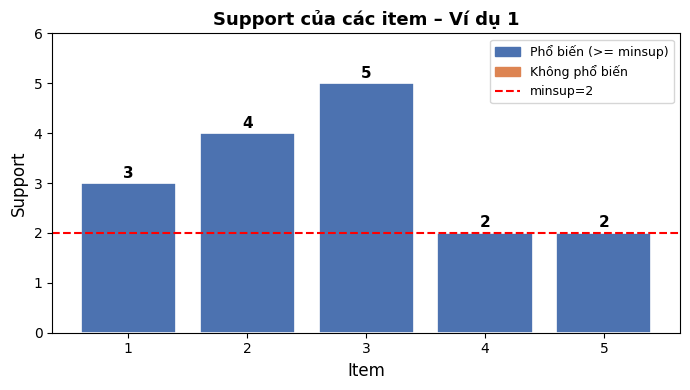

In [25]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(7, 4))
items_sorted = sorted(item_sup.keys())
supports = [item_sup[i] for i in items_sorted]
colors = ['#4C72B0' if item_sup[i] >= MINSUP else '#DD8452' for i in items_sorted]
bars = ax.bar([str(i) for i in items_sorted], supports, color=colors, edgecolor='white', linewidth=1.2)
ax.axhline(MINSUP, color='red', linestyle='--', linewidth=1.5, label=f'minsup = {MINSUP}')
for bar, sup in zip(bars, supports):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, str(sup),
            ha='center', va='bottom', fontsize=11, fontweight='bold')
freq_patch = mpatches.Patch(color='#4C72B0', label='Phổ biến (>= minsup)')
infreq_patch = mpatches.Patch(color='#DD8452', label='Không phổ biến')
ax.legend(handles=[freq_patch, infreq_patch, plt.Line2D([0],[0],color='red',linestyle='--',label=f'minsup={MINSUP}')], fontsize=9)
ax.set_xlabel('Item', fontsize=12)
ax.set_ylabel('Support', fontsize=12)
ax.set_title('Support của các item – Ví dụ 1', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(supports) + 1)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

### 1.3 Bước 2 – Xây dựng PPC-tree

**Quy tắc xây dựng PPC-tree:**
- Mỗi giao dịch được sắp xếp lại theo `order_map` (thứ tự item phổ biến) trước khi chèn.
- Cây có nút gốc `root`; mỗi nút lưu: `item`, `count`, `children`, `parent`.
- Sau khi xây xong cây, gán **pre-order** (DFS pre) và **post-order** (DFS post) cho từng nút.

**Ý nghĩa pre-order / post-order:**

| Số thứ tự | Ý nghĩa |
|-----------|---------|
| `pre` | Thứ tự thăm nút **trước** khi thăm con (DFS vào) |
| `post` | Thứ tự thăm nút **sau** khi thăm hết con (DFS ra) |

**Quan hệ tổ tiên–con cháu qua pre/post:**  
Nút `u` là **tổ tiên** của nút `v` khi và chỉ khi:
```
u.pre < v.pre  VÀ  u.post > v.post
```
Đây là nền tảng để thực hiện phép giao N-list mà không cần duyệt lại cây.

**Minh họa chèn T1 = [1, 2, 3] (sau khi sắp xếp theo order_map):**
```
root
 └─ item=3 (cnt=1)
     └─ item=2 (cnt=1)
         └─ item=1 (cnt=1)
```
Các giao dịch tiếp theo sẽ chia sẻ prefix nếu có cùng đầu chuỗi.

In [26]:
#  Cấu trúc nút PPC-tree
class PPCNode:
    def __init__(self, item, parent=None):
        self.item    = item       # None = root
        self.count   = 0
        self.parent  = parent
        self.children = {}        # item -> PPCNode
        self.pre     = -1         # pre-order number
        self.post    = -1         # post-order number

    def __repr__(self):
        return f'Node(item={self.item}, cnt={self.count}, pre={self.pre}, post={self.post})'


def build_ppc_tree(transactions, freq_items, order_map):
    root = PPCNode(item=None)
    # Chèn từng giao dịch
    for t in transactions:
        # Lọc & sắp xếp theo thứ tự phổ biến
        sorted_t = sorted(
            [x for x in t if x in order_map],
            key=lambda x: order_map[x]
        )
        node = root
        for item in sorted_t:
            if item not in node.children:
                node.children[item] = PPCNode(item=item, parent=node)
            node.children[item].count += 1
            node = node.children[item]
    return root


def assign_pre_post(root):
    """Gán số pre-order và post-order bằng DFS."""
    pre_counter  = [0]
    post_counter = [0]

    def dfs(node):
        node.pre = pre_counter[0]
        pre_counter[0] += 1
        for child in node.children.values():
            dfs(child)
        node.post = post_counter[0]
        post_counter[0] += 1

    dfs(root)


def print_tree(node, indent=0, freq_items=None):
    """In cây theo dạng thụt lề."""
    if node.item is None:
        label = '[root]'
    else:
        label = f'item={node.item}  cnt={node.count}  pre={node.pre}  post={node.post}'
    print(' ' * indent + label)
    for child in node.children.values():
        print_tree(child, indent + 4)


# ── Xây cây & gán số thứ tự
tree = build_ppc_tree(transactions, freq_items, order_map)
assign_pre_post(tree)

print('=== CẤU TRÚC PPC-TREE ===')
print_tree(tree)

=== CẤU TRÚC PPC-TREE ===
[root]
    item=3  cnt=5  pre=1  post=7
        item=2  cnt=4  pre=2  post=4
            item=1  cnt=2  pre=3  post=1
                item=5  cnt=1  pre=4  post=0
            item=5  cnt=1  pre=5  post=2
            item=4  cnt=1  pre=6  post=3
        item=1  cnt=1  pre=7  post=6
            item=4  cnt=1  pre=8  post=5


###  Visualization 2 – PPC-tree dạng đồ thị (Ví dụ 1)

> Mỗi nút hiển thị `item`, `count`, `pre` và `post`. Nút gốc màu xám, các nút item màu xanh dương với độ đậm tỉ lệ với count.

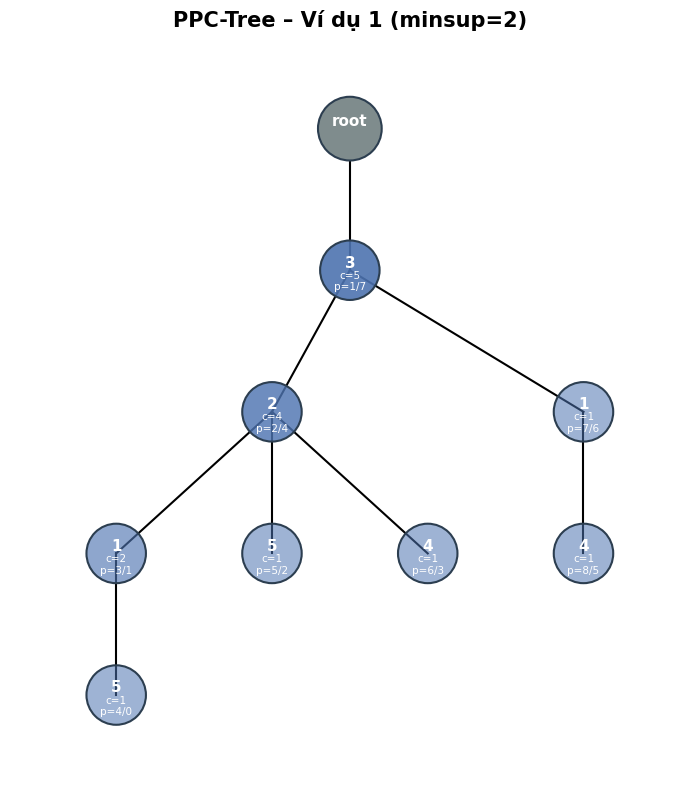

In [44]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# Count leaves of each subtree
# --------------------------------------------------
def count_leaves(node):
    children = list(node.children.values())
    if not children:
        return 1
    return sum(count_leaves(child) for child in children)

# --------------------------------------------------
# Compute positions using subtree widths
# --------------------------------------------------
def assign_positions(node, x=0.0, y=0.0, x_unit=1.8, y_gap=2.0, pos=None, nodes=None):
    if pos is None:
        pos = {}
        nodes = []

    pos[id(node)] = (x, y)
    nodes.append(node)

    children = list(node.children.values())
    if not children:
        return pos, nodes

    leaf_counts = [count_leaves(child) for child in children]
    total_width = sum(leaf_counts)

    start = x - (total_width * x_unit) / 2.0
    current = start

    for child, width in zip(children, leaf_counts):
        child_center = current + (width * x_unit) / 2.0
        assign_positions(child, child_center, y - y_gap, x_unit, y_gap, pos, nodes)
        current += width * x_unit

    return pos, nodes

# --------------------------------------------------
# Draw PPC-tree
# --------------------------------------------------
def draw_ppc_tree(root, title='PPC-Tree'):
    pos, nodes = assign_positions(root, x=0.0, y=0.0, x_unit=2.2, y_gap=2.0)

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_aspect('equal')

    # Draw edges
    for node in nodes:
        if node.parent is not None and id(node.parent) in pos:
            x0, y0 = pos[id(node.parent)]
            x1, y1 = pos[id(node)]
            ax.plot([x0, x1], [y0, y1], color='black', linewidth=1.5, zorder=1)

    # Max count for visual scaling
    max_cnt = max((n.count for n in nodes if n.item is not None), default=1)

    # Draw nodes
    for node in nodes:
        x, y = pos[id(node)]

        if node.item is None:
            color = '#7f8c8d'
            label_main = 'root'
            label_sub = ''
            radius = 0.45
        else:
            alpha = 0.45 + 0.45 * (node.count / max_cnt)
            color = (0.30, 0.45, 0.69, alpha)
            label_main = f'{node.item}'
            label_sub = f'c={node.count}\np={node.pre}/{node.post}'
            radius = 0.42

        circle = plt.Circle(
            (x, y),
            radius,
            facecolor=color,
            edgecolor='#2c3e50',
            linewidth=1.5,
            zorder=2
        )
        ax.add_patch(circle)

        ax.text(
            x, y + 0.10,
            label_main,
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            color='white', zorder=3
        )

        if label_sub:
            ax.text(
                x, y - 0.16,
                label_sub,
                ha='center', va='center',
                fontsize=7.5,
                color='white',
                zorder=3
            )

    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]

    ax.set_xlim(min(xs) - 1.5, max(xs) + 1.5)
    ax.set_ylim(min(ys) - 1.2, max(ys) + 1.2)
    ax.axis('off')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)

    plt.tight_layout()
    plt.show()

draw_ppc_tree(tree, title='PPC-Tree – Ví dụ 1 (minsup=2)')

### 1.4 Bước 3 – Xây dựng N-list cho 1-itemset

**Định nghĩa N-list:** N-list của item `x` là danh sách các bộ ba `(pre, post, count)` của **tất cả nút mang nhãn `x`** trên PPC-tree, sắp xếp theo chiều tăng của `pre`.

**Support** của itemset được tính bằng **tổng `count`** của các phần tử trong N-list.

$$\text{support}(x) = \sum_{(p,q,c) \in NL(x)} c$$

**Quan hệ tổ tiên–con cháu** (dùng để giao N-list):  
Nút `u` là **tổ tiên** của nút `v` khi và chỉ khi: `u.pre < v.pre` **và** `u.post > v.post`.

>  **Tại sao lưu `count` thay vì liệt kê TID?**  
> Nhiều giao dịch có thể chia sẻ cùng một nút trên cây (do prefix chung),  
> nên `count` của nút bằng số giao dịch đi qua nút đó — tiết kiệm bộ nhớ hơn nhiều so với lưu từng TID.

In [28]:
#  Thu thập tất cả nút theo item
def collect_nodes(root):
    """Trả về dict: item -> list of PPCNode."""
    node_map = defaultdict(list)
    stack = [root]
    while stack:
        node = stack.pop()
        if node.item is not None:
            node_map[node.item].append(node)
        stack.extend(node.children.values())
    # Sắp xếp theo pre-order
    for item in node_map:
        node_map[item].sort(key=lambda n: n.pre)
    return node_map


node_map = collect_nodes(tree)

# N-list biểu diễn bằng list of (pre, post, count)
def build_nlist_1item(item, node_map):
    return [(n.pre, n.post, n.count) for n in node_map[item]]

nlist_1 = {item: build_nlist_1item(item, node_map) for item in freq_items}

print('=== N-LIST CỦA TỪNG 1-ITEMSET PHỔ BIẾN ===')
rows = []
for item in freq_items:
    sup = sum(c for _, _, c in nlist_1[item])
    entries = ', '.join(f'({p},{q},{c})' for p, q, c in nlist_1[item])
    rows.append({'Item': item, 'N-list (pre, post, cnt)': entries, 'Support': sup})
df_nlist1 = pd.DataFrame(rows)
print(df_nlist1.to_string(index=False))

=== N-LIST CỦA TỪNG 1-ITEMSET PHỔ BIẾN ===
 Item N-list (pre, post, cnt)  Support
    3                 (1,7,5)        5
    2                 (2,4,4)        4
    1        (3,1,2), (7,6,1)        3
    4        (6,3,1), (8,5,1)        2
    5        (4,0,1), (5,2,1)        2


### 1.5 Bước 4 – Phép giao N-list (intersection)

**Quy tắc giao hai N-list** (để sinh N-list của `P ∪ {x}` từ N-list của `P` và N-list của `{x}`):

```
Cho NL(P) và NL(x), với mỗi cặp (u ∈ NL(P), v ∈ NL(x)):
  Nếu v là con cháu của u  → thêm (v.pre, v.post, v.count) vào NL(P∪{x})
  Nếu u là con cháu của v  → thêm (u.pre, u.post, u.count) vào NL(P∪{x})  [chỉ trong PrePost+]
```

> Ở phiên bản PrePost gốc (Deng et al. 2012), chỉ trường hợp **v là con cháu của u** được dùng khi duyệt theo chiều sâu.

**Kiểm tra con cháu:** `is_descendant(u, v)` ↔ `u.pre < v.pre` và `u.post > v.post`

**Ví dụ minh họa:**

Giả sử `NL({3}) = [(1, 8, 3)]` và `NL({2}) = [(3, 5, 2), (6, 7, 1)]`

| u (từ NL(3)) | v (từ NL(2)) | v là con cháu u? | Kết quả |
|---|---|---|---|
| (1, 8, 3) | (3, 5, 2) | 1 < 3 và 8 > 5 →  | Thêm (3, 5, 2) |
| (1, 8, 3) | (6, 7, 1) | 1 < 6 và 8 > 7 →  | Thêm (6, 7, 1) |

→ `NL({3,2}) = [(3,5,2), (6,7,1)]`, support = 2 + 1 = **3**

> ️ **Tối ưu quan trọng:** Vì cả hai N-list đều sắp xếp theo `pre`, ta có thể dùng **two-pointer** để giao trong O(|NL(P)| + |NL(x)|) thay vì O(|NL(P)| × |NL(x)|).

In [29]:
#  Phép giao N-list
def is_descendant(u_pre, u_post, v_pre, v_post):
    """Kiểm tra v có phải con cháu của u không."""
    return u_pre < v_pre and u_post > v_post


def intersect_nlist(nl_p, nl_x, verbose=False, label_p='P', label_x='x'):
    """
    Giao N-list của P (nl_p) và N-list của {x} (nl_x).
    Trả về N-list của P ∪ {x}.
    """
    result = []
    if verbose:
        print(f'  Giao NL({label_p}) × NL({label_x}):')
    for u_pre, u_post, u_cnt in nl_p:
        for v_pre, v_post, v_cnt in nl_x:
            if is_descendant(u_pre, u_post, v_pre, v_post):
                result.append((v_pre, v_post, v_cnt))
                if verbose:
                    print(f'    u=({u_pre},{u_post},{u_cnt}) ⊃ v=({v_pre},{v_post},{v_cnt}) → thêm v')
    # Hợp nhất các cặp (pre, post) trùng nhau (cộng count)
    merged = {}
    for pre, post, cnt in result:
        key = (pre, post)
        merged[key] = merged.get(key, 0) + cnt
    final = [(pre, post, cnt) for (pre, post), cnt in sorted(merged.items())]
    sup = sum(c for _, _, c in final)
    if verbose:
        print(f'    → NL({label_p}∪{{{label_x}}}) = {final}  |  support = {sup}')
    return final, sup


# ── Minh họa: giao NL(3) và NL(2)
print('=== VÍ DỤ PHÉP GIAO: NL({3}) ∩-kiểu NL({2}) ===')
_, _ = intersect_nlist(nlist_1[3], nlist_1[2], verbose=True, label_p='{3}', label_x='{2}')

=== VÍ DỤ PHÉP GIAO: NL({3}) ∩-kiểu NL({2}) ===
  Giao NL({3}) × NL({2}):
    u=(1,7,5) ⊃ v=(2,4,4) → thêm v
    → NL({3}∪{{2}}) = [(2, 4, 4)]  |  support = 4


### 1.6 Bước 5 – Thuật toán PrePost đệ quy (duyệt sinh itemset phổ biến)

**Lược đồ thuật toán (pseudocode):**
```
PrePost(P, NL(P), items_after_P):
    for each item x in items_after_P:
        NL(P∪{x}), sup = intersect(NL(P), NL({x}))
        if sup >= minsup:
            output P∪{x} with sup
            PrePost(P∪{x}, NL(P∪{x}), items_after_x_in_items_after_P)
```

**Chiến lược duyệt (DFS theo không gian itemset):**

```
Tầng 1 (1-itemset phổ biến):  {3}, {2}, {1}, {5}, {4}
                                 │
Tầng 2 (extend {3}):    {3,2}, {3,1}, {3,5}, {3,4}
                           │
Tầng 3 (extend {3,2}): {3,2,1}, {3,2,5}, {3,2,4}
                           ...
```

**Điều kiện cắt nhánh (pruning):**  
Nếu `support(P∪{x}) < minsup` → **không đệ quy sâu hơn**.  
Theo tính chất **antimonotone**: mọi superset của itemset không phổ biến đều không phổ biến.

**Độ phức tạp không gian:**  
Mỗi mức đệ quy chỉ cần lưu N-list hiện tại — không cần xây lại conditional tree như FP-Growth.

In [30]:
#  Thuật toán PrePost đệ quy
frequent_itemsets_basic = {}   # frozenset -> support
step_log = []                  # ghi lại từng bước để in bảng

def prepost(prefix, nl_prefix, remaining_items, depth=0):
    for i, item in enumerate(remaining_items):
        nl_item = nlist_1[item]
        nl_new, sup = intersect_nlist(nl_prefix, nl_item)
        candidate = prefix + [item]
        status = '' if sup >= MINSUP else ''
        step_log.append({
            'Bước': len(step_log) + 1,
            'Itemset': str(candidate),
            'N-list': str(nl_new),
            'Support': sup,
            'Kết quả': status
        })
        if sup >= MINSUP:
            frequent_itemsets_basic[frozenset(candidate)] = sup
            next_items = remaining_items[i+1:]
            if next_items:
                prepost(candidate, nl_new, next_items, depth + 1)

# Khởi động: coi root có N-list = [(root.pre, root.post, Σcount)]
# Để khởi tạo đúng, dùng N-list "toàn bộ" = giả lập nút root
# Root: pre=0, post=max_post; count=tổng giao dịch (không ảnh hưởng vì root không là tổ tiên thực sự)
# → Thay vào đó, gọi trực tiếp từng 1-itemset làm prefix ban đầu

# Thêm 1-itemset vào kết quả
for item in freq_items:
    sup_1 = sum(c for _, _, c in nlist_1[item])
    frequent_itemsets_basic[frozenset([item])] = sup_1

# Gọi đệ quy sinh k-itemset (k >= 2)
for i, item in enumerate(freq_items):
    remaining = freq_items[i+1:]
    if remaining:
        prepost([item], nlist_1[item], remaining)

print('=== CÁC BƯỚC GIAO N-LIST TRUNG GIAN ===')
df_steps = pd.DataFrame(step_log)
print(df_steps.to_string(index=False))

=== CÁC BƯỚC GIAO N-LIST TRUNG GIAN ===
 Bước      Itemset                 N-list  Support Kết quả
    1       [3, 2]            [(2, 4, 4)]        4        
    2    [3, 2, 1]            [(3, 1, 2)]        2        
    3 [3, 2, 1, 4]                     []        0        
    4 [3, 2, 1, 5]            [(4, 0, 1)]        1        
    5    [3, 2, 4]            [(6, 3, 1)]        1        
    6    [3, 2, 5] [(4, 0, 1), (5, 2, 1)]        2        
    7       [3, 1] [(3, 1, 2), (7, 6, 1)]        3        
    8    [3, 1, 4]            [(8, 5, 1)]        1        
    9    [3, 1, 5]            [(4, 0, 1)]        1        
   10       [3, 4] [(6, 3, 1), (8, 5, 1)]        2        
   11    [3, 4, 5]                     []        0        
   12       [3, 5] [(4, 0, 1), (5, 2, 1)]        2        
   13       [2, 1]            [(3, 1, 2)]        2        
   14    [2, 1, 4]                     []        0        
   15    [2, 1, 5]            [(4, 0, 1)]        1        
   16       [2, 

###  Visualization 5 – Kết quả các bước giao N-list (Ví dụ 1)

> Biểu đồ cột ngang hiển thị support của từng candidate itemset. Màu xanh = phổ biến (≥ minsup), màu cam = không phổ biến. Đường dọc đỏ là ngưỡng minsup.

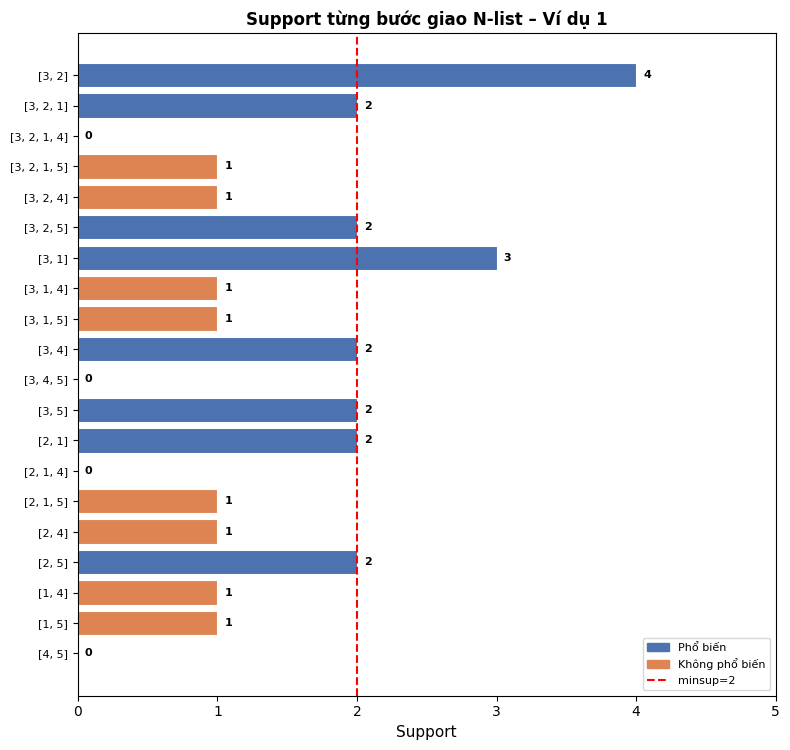

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels = [row['Itemset'] for row in step_log]
supports_s = [row['Support'] for row in step_log]
colors_s = ['#4C72B0' if s >= MINSUP else '#DD8452' for s in supports_s]

fig, ax = plt.subplots(figsize=(8, max(4, len(labels) * 0.38)))
bars = ax.barh(range(len(labels)), supports_s, color=colors_s, edgecolor='white', linewidth=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.axvline(MINSUP, color='red', linestyle='--', linewidth=1.5, label=f'minsup={MINSUP}')
for bar, sup in zip(bars, supports_s):
    ax.text(sup + 0.05, bar.get_y() + bar.get_height()/2, str(sup),
            va='center', fontsize=8, fontweight='bold')
freq_p = mpatches.Patch(color='#4C72B0', label='Phổ biến')
infreq_p = mpatches.Patch(color='#DD8452', label='Không phổ biến')
ax.legend(handles=[freq_p, infreq_p, plt.Line2D([0],[0],color='red',linestyle='--',label=f'minsup={MINSUP}')], fontsize=8, loc='lower right')
ax.set_xlabel('Support', fontsize=11)
ax.set_title('Support từng bước giao N-list – Ví dụ 1', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(supports_s) + 1)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

### 1.7 Tập kết quả cuối cùng

> ** Kỳ vọng:** Với `minsup = 2` trên 5 giao dịch, ta kỳ vọng tìm được tất cả itemset xuất hiện ít nhất 2 lần.  
> Kết quả sẽ được so sánh với brute-force ở Mục 3 để xác nhận tính đúng đắn.

In [32]:
print(f'=== TẬP PHỔ BIẾN (minsup={MINSUP}) – VÍ DỤ 1 ===')
rows = []
for fs, sup in sorted(frequent_itemsets_basic.items(), key=lambda x: (len(x[0]), sorted(x[0]))):
    rows.append({'Itemset': str(sorted(fs)), 'Support': sup})
df_result1 = pd.DataFrame(rows)
print(df_result1.to_string(index=False))
print(f'\nTổng số itemset phổ biến: {len(frequent_itemsets_basic)}')

=== TẬP PHỔ BIẾN (minsup=2) – VÍ DỤ 1 ===
  Itemset  Support
      [1]        3
      [2]        4
      [3]        5
      [4]        2
      [5]        2
   [1, 2]        2
   [1, 3]        3
   [2, 3]        4
   [2, 5]        2
   [3, 4]        2
   [3, 5]        2
[1, 2, 3]        2
[2, 3, 5]        2

Tổng số itemset phổ biến: 13


### ️ Visualization 3 – Heatmap support các cặp 2-itemset (Ví dụ 1)

> Ma trận thể hiện support của mọi cặp 2-itemset phổ biến. Ô màu xanh đậm = support cao; ô xám = không phổ biến (< minsup).

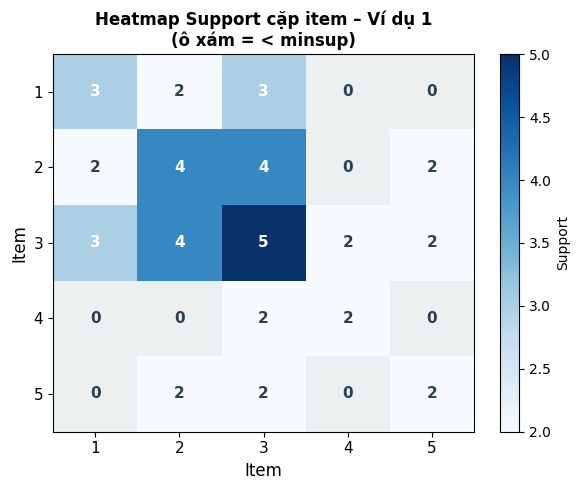

In [33]:
import matplotlib.pyplot as plt
import numpy as np

items_list = sorted(freq_items)
n = len(items_list)
matrix = np.full((n, n), np.nan)
for i, a in enumerate(items_list):
    for j, b in enumerate(items_list):
        if i == j:
            matrix[i][j] = item_sup[a]
        elif i < j:
            key = frozenset([a, b])
            sup = frequent_itemsets_basic.get(key, 0)
            matrix[i][j] = sup
            matrix[j][i] = sup

fig, ax = plt.subplots(figsize=(6, 5))
cmap = plt.cm.Blues.copy()
cmap.set_under('#ecf0f1')
im = ax.imshow(matrix, cmap=cmap, vmin=MINSUP, vmax=max(item_sup.values()), aspect='auto')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
labels = [str(i) for i in items_list]
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Item', fontsize=12); ax.set_ylabel('Item', fontsize=12)
for i in range(n):
    for j in range(n):
        val = matrix[i][j]
        txt = str(int(val)) if not np.isnan(val) else ''
        color_txt = 'white' if val >= MINSUP + 1 else '#2c3e50'
        ax.text(j, i, txt, ha='center', va='center', fontsize=11, fontweight='bold', color=color_txt)
plt.colorbar(im, ax=ax, label='Support')
ax.set_title('Heatmap Support cặp item – Ví dụ 1\n(ô xám = < minsup)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='crosscheck'></a>
## 3. Cross-check kết quả – Ví dụ 1

### 3.1 Liệt kê thủ công tất cả itemset phổ biến bằng brute-force

**Phương pháp kiểm tra chéo:** duyệt **toàn bộ** tập con của tập item phổ biến,  
đếm support thực tế trên CSDL, so sánh với kết quả PrePost.

**Tại sao cần cross-check?**
- Brute-force đảm bảo **không bỏ sót** itemset nào.
- So sánh hai chiều: itemset trong PrePost mà không có trong brute-force → **False Positive**; ngược lại → **False Negative**.
- Đây là bước kiểm tra **đúng đắn (correctness)** của cài đặt.

> ️ Brute-force có độ phức tạp $O(2^n)$ với $n$ là số item phổ biến — chỉ dùng được với CSDL nhỏ như ví dụ minh họa.

In [34]:
def brute_force_frequent(transactions, minsup):
    """Liệt kê tất cả itemset phổ biến bằng brute-force."""
    all_items = sorted({item for t in transactions for item in t})
    result = {}
    for size in range(1, len(all_items) + 1):
        for combo in combinations(all_items, size):
            combo_set = set(combo)
            sup = sum(1 for t in transactions if combo_set.issubset(t))
            if sup >= minsup:
                result[frozenset(combo)] = sup
    return result


brute_basic = brute_force_frequent(transactions, MINSUP)

print(f'=== BRUTE-FORCE (minsup={MINSUP}) ===')
rows_bf = []
for fs, sup in sorted(brute_basic.items(), key=lambda x: (len(x[0]), sorted(x[0]))):
    rows_bf.append({'Itemset': str(sorted(fs)), 'Support (brute)': sup})
df_bf1 = pd.DataFrame(rows_bf)
print(df_bf1.to_string(index=False))
print(f'\nTổng: {len(brute_basic)}')

=== BRUTE-FORCE (minsup=2) ===
  Itemset  Support (brute)
      [1]                3
      [2]                4
      [3]                5
      [4]                2
      [5]                2
   [1, 2]                2
   [1, 3]                3
   [2, 3]                4
   [2, 5]                2
   [3, 4]                2
   [3, 5]                2
[1, 2, 3]                2
[2, 3, 5]                2

Tổng: 13


In [35]:
# ── So sánh PrePost vs Brute-force
def compare_results(prepost_res, brute_res, label=''):
    pp_keys  = set(prepost_res.keys())
    bf_keys  = set(brute_res.keys())
    only_pp  = pp_keys - bf_keys
    only_bf  = bf_keys - pp_keys
    common   = pp_keys & bf_keys
    sup_mismatch = [
        (sorted(fs), prepost_res[fs], brute_res[fs])
        for fs in common if prepost_res[fs] != brute_res[fs]
    ]

    print(f'=== CROSS-CHECK {label} ===')
    print(f'  PrePost tìm được : {len(pp_keys)} itemset')
    print(f'  Brute-force      : {len(bf_keys)} itemset')
    if not only_pp and not only_bf and not sup_mismatch:
        print('TRUE - KẾT QUẢ HOÀN TOÀN KHỚP!')
    else:
        if only_pp:
            print(f'FAIL - Chỉ PrePost có: {[sorted(s) for s in only_pp]}')
        if only_bf:
            print(f'FAIL - Chỉ Brute-force có: {[sorted(s) for s in only_bf]}')
        if sup_mismatch:
            print(f'FAIL - Support sai: {sup_mismatch}')

compare_results(frequent_itemsets_basic, brute_basic, label='VÍ DỤ 1')

=== CROSS-CHECK VÍ DỤ 1 ===
  PrePost tìm được : 13 itemset
  Brute-force      : 13 itemset
TRUE - KẾT QUẢ HOÀN TOÀN KHỚP!


### 3.2 So sánh với file expected

> **Mục đích:** Nếu có sẵn file kết quả chuẩn (generated từ tool reference như SPMF),  
> ta so sánh thêm một lần nữa để đảm bảo tuyệt đối.  
> File expected có dạng mỗi dòng: `item1 item2 ... #SUP: support`

In [36]:
EXPECTED_PATH = os.path.join('..', 'data', 'toy', 'expected', 'example_basic_minsup2.out')

def load_expected(path):
    """Đọc file expected dạng: '1 2 3 #SUP: 5'"""
    result = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('#SUP:')
            items = frozenset(map(int, parts[0].strip().split()))
            sup   = int(parts[1].strip())
            result[items] = sup
    return result

if os.path.exists(EXPECTED_PATH):
    expected_basic = load_expected(EXPECTED_PATH)
    compare_results(frequent_itemsets_basic, expected_basic, label='VÍ DỤ 1 vs FILE EXPECTED')
else:
    print('Không tìm thấy file expected. Chỉ dùng brute-force để cross-check.')

=== CROSS-CHECK VÍ DỤ 1 vs FILE EXPECTED ===
  PrePost tìm được : 13 itemset
  Brute-force      : 13 itemset
TRUE - KẾT QUẢ HOÀN TOÀN KHỚP!


---
<a id='example2'></a>
## 2. Ví dụ 2 – Đặc biệt (Single-path tree)

### 2.1 CSDL đặc biệt

| TID | Giao dịch    |
|-----|-------------|
| T1  | 1, 2, 3, 4  |
| T2  | 1, 2, 3     |
| T3  | 1, 2, 3, 4  |
| T4  | 1, 2, 3     |
| T5  | 1, 2        |

**Đặc điểm:** Mọi giao dịch đều chia sẻ prefix `1, 2` → PPC-tree tạo thành **một nhánh duy nhất** (single path).  
Đây là trường hợp đặc biệt cần minh họa riêng.

**Tham số:** `minsup = 2`

**Tại sao single-path quan trọng?**  
- PPC-tree suy biến thành **danh sách liên kết** (linked list) thay vì cây phân nhánh.
- Mỗi item chỉ có **đúng một nút** trên cây → N-list chỉ có một phần tử.
- Phép giao N-list đơn giản hơn nhiều, nhưng kết quả itemset phổ biến có thể rất nhiều (tất cả tập con của path đều phổ biến nếu support đủ cao).
- Đây là **worst case về số lượng kết quả** nhưng **best case về chi phí giao N-list**.

In [37]:
DATA_PATH_2 = os.path.join('..', 'data', 'toy', 'example_special_single_path.txt')

if os.path.exists(DATA_PATH_2):
    transactions2 = load_transactions(DATA_PATH_2)
else:
    transactions2 = [
        [1, 2, 3, 4],
        [1, 2, 3],
        [1, 2, 3, 4],
        [1, 2, 3],
        [1, 2],
    ]
    print(' Không tìm thấy file, dùng dữ liệu nhúng sẵn.')

df_db2 = pd.DataFrame({
    'TID': [f'T{i+1}' for i in range(len(transactions2))],
    'Giao dịch': [str(t) for t in transactions2]
})
print('=== CSDL GỐC – VÍ DỤ 2 ===')
print(df_db2.to_string(index=False))

=== CSDL GỐC – VÍ DỤ 2 ===
TID    Giao dịch
 T1 [1, 2, 3, 4]
 T2    [1, 2, 3]
 T3 [1, 2, 3, 4]
 T4    [1, 2, 3]
 T5       [1, 2]


### 2.2 Support 1-itemset & thứ tự PPC-tree

> **Kỳ vọng:** Do mọi giao dịch đều chứa `1` và `2`, hai item này sẽ có support = 5 (100%).  
> Item `3` có support = 4, item `4` có support = 2.  
> Thứ tự chèn cây sẽ là: `1 → 2 → 3 → 4` (giảm dần support).

In [38]:
MINSUP2 = 2

item_sup2 = defaultdict(int)
for t in transactions2:
    for item in t:
        item_sup2[item] += 1

freq_items2 = sorted(
    [item for item, sup in item_sup2.items() if sup >= MINSUP2],
    key=lambda x: (-item_sup2[x], x)
)
order_map2 = {item: idx for idx, item in enumerate(freq_items2)}

print('Support từng item:')
df_sup2 = pd.DataFrame([
    {'Item': item, 'Support': item_sup2[item], 'Phổ biến?': '' if item_sup2[item] >= MINSUP2 else ''}
    for item in sorted(item_sup2.keys())
])
print(df_sup2.to_string(index=False))
print(f'\nThứ tự chèn PPC-tree: {freq_items2}')

Support từng item:
 Item  Support Phổ biến?
    1        5          
    2        5          
    3        4          
    4        2          

Thứ tự chèn PPC-tree: [1, 2, 3, 4]


### 2.3 Xây dựng PPC-tree & N-list – Ví dụ 2

> **Kỳ vọng cấu trúc PPC-tree (single path):**
> ```
> [root]
>     item=1  cnt=5  
>         item=2  cnt=5  
>             item=3  cnt=4  
>                 item=4  cnt=2
> ```
> Vì mọi giao dịch đều có prefix `1, 2`, không có phân nhánh nào xuất hiện.
>
> **N-list của mỗi item** sẽ chỉ có **một phần tử** `(pre, post, count)`,  
> vì mỗi item chỉ xuất hiện đúng một lần trên cây single-path.

In [39]:
tree2 = build_ppc_tree(transactions2, freq_items2, order_map2)
assign_pre_post(tree2)

print('=== PPC-TREE – VÍ DỤ 2 (SINGLE PATH) ===')
print_tree(tree2)

node_map2 = collect_nodes(tree2)
nlist_1_2  = {item: build_nlist_1item(item, node_map2) for item in freq_items2}

print('\n=== N-LIST 1-ITEMSET – VÍ DỤ 2 ===')
rows2 = []
for item in freq_items2:
    sup = sum(c for _, _, c in nlist_1_2[item])
    entries = ', '.join(f'({p},{q},{c})' for p, q, c in nlist_1_2[item])
    rows2.append({'Item': item, 'N-list (pre, post, cnt)': entries, 'Support': sup})
print(pd.DataFrame(rows2).to_string(index=False))

=== PPC-TREE – VÍ DỤ 2 (SINGLE PATH) ===
[root]
    item=1  cnt=5  pre=1  post=3
        item=2  cnt=5  pre=2  post=2
            item=3  cnt=4  pre=3  post=1
                item=4  cnt=2  pre=4  post=0

=== N-LIST 1-ITEMSET – VÍ DỤ 2 ===
 Item N-list (pre, post, cnt)  Support
    1                 (1,3,5)        5
    2                 (2,2,5)        5
    3                 (3,1,4)        4
    4                 (4,0,2)        2


### 2.4 Chạy PrePost – Ví dụ 2

> **Kỳ vọng kết quả:** Vì đây là single-path tree với 4 item phổ biến (`1, 2, 3, 4`),  
> tất cả tập con có support ≥ minsup đều là phổ biến.  
> Cụ thể: `{1}`, `{2}`, `{3}`, `{4}`, `{1,2}`, `{1,3}`, `{2,3}`, `{1,4}`, `{2,4}`, `{3,4}`, `{1,2,3}`, `{1,2,4}`, `{1,3,4}`, `{2,3,4}`, `{1,2,3,4}` (nếu tất cả vượt minsup).
>
>  **Quan sát khi chạy:** Phép giao N-list trong single-path sẽ luôn thành công (v luôn là con cháu của u theo đường thẳng), nên support = count của nút sâu hơn.

In [40]:
frequent_itemsets_special = {}
step_log2 = []

def prepost_v2(prefix, nl_prefix, remaining_items):
    for i, item in enumerate(remaining_items):
        nl_item = nlist_1_2[item]
        nl_new, sup = intersect_nlist(nl_prefix, nl_item)
        candidate = prefix + [item]
        status = '' if sup >= MINSUP2 else ''
        step_log2.append({
            'Bước': len(step_log2) + 1,
            'Itemset': str(candidate),
            'N-list': str(nl_new),
            'Support': sup,
            'Kết quả': status
        })
        if sup >= MINSUP2:
            frequent_itemsets_special[frozenset(candidate)] = sup
            next_items = remaining_items[i+1:]
            if next_items:
                prepost_v2(candidate, nl_new, next_items)

for item in freq_items2:
    sup_1 = sum(c for _, _, c in nlist_1_2[item])
    frequent_itemsets_special[frozenset([item])] = sup_1

for i, item in enumerate(freq_items2):
    remaining = freq_items2[i+1:]
    if remaining:
        prepost_v2([item], nlist_1_2[item], remaining)

print('=== CÁC BƯỚC GIAO N-LIST – VÍ DỤ 2 ===')
print(pd.DataFrame(step_log2).to_string(index=False))

print(f'\n=== TẬP PHỔ BIẾN (minsup={MINSUP2}) – VÍ DỤ 2 ===')
rows_sp = []
for fs, sup in sorted(frequent_itemsets_special.items(), key=lambda x: (len(x[0]), sorted(x[0]))):
    rows_sp.append({'Itemset': str(sorted(fs)), 'Support': sup})
print(pd.DataFrame(rows_sp).to_string(index=False))
print(f'\nTổng: {len(frequent_itemsets_special)}')

=== CÁC BƯỚC GIAO N-LIST – VÍ DỤ 2 ===
 Bước      Itemset      N-list  Support Kết quả
    1       [1, 2] [(2, 2, 5)]        5        
    2    [1, 2, 3] [(3, 1, 4)]        4        
    3 [1, 2, 3, 4] [(4, 0, 2)]        2        
    4    [1, 2, 4] [(4, 0, 2)]        2        
    5       [1, 3] [(3, 1, 4)]        4        
    6    [1, 3, 4] [(4, 0, 2)]        2        
    7       [1, 4] [(4, 0, 2)]        2        
    8       [2, 3] [(3, 1, 4)]        4        
    9    [2, 3, 4] [(4, 0, 2)]        2        
   10       [2, 4] [(4, 0, 2)]        2        
   11       [3, 4] [(4, 0, 2)]        2        

=== TẬP PHỔ BIẾN (minsup=2) – VÍ DỤ 2 ===
     Itemset  Support
         [1]        5
         [2]        5
         [3]        4
         [4]        2
      [1, 2]        5
      [1, 3]        4
      [1, 4]        2
      [2, 3]        4
      [2, 4]        2
      [3, 4]        2
   [1, 2, 3]        4
   [1, 2, 4]        2
   [1, 3, 4]        2
   [2, 3, 4]        2
[1, 2, 3, 4]

### 2.5 Cross-check – Ví dụ 2

> **Mục đích:** Xác nhận PrePost không bỏ sót hoặc sinh thừa itemset trong trường hợp single-path.  
> Đây là kiểm tra quan trọng vì single-path là edge case của thuật toán.

In [41]:
brute_special = brute_force_frequent(transactions2, MINSUP2)
compare_results(frequent_itemsets_special, brute_special, label='VÍ DỤ 2 (SINGLE PATH)')

EXPECTED_PATH_2 = os.path.join('..', 'data', 'toy', 'expected', 'example_special_minsup2.out')
if os.path.exists(EXPECTED_PATH_2):
    expected_special = load_expected(EXPECTED_PATH_2)
    compare_results(frequent_itemsets_special, expected_special, label='VÍ DỤ 2 vs FILE EXPECTED')
else:
    print('Không tìm thấy file expected.')

=== CROSS-CHECK VÍ DỤ 2 (SINGLE PATH) ===
  PrePost tìm được : 15 itemset
  Brute-force      : 15 itemset
TRUE - KẾT QUẢ HOÀN TOÀN KHỚP!
=== CROSS-CHECK VÍ DỤ 2 vs FILE EXPECTED ===
  PrePost tìm được : 15 itemset
  Brute-force      : 15 itemset
TRUE - KẾT QUẢ HOÀN TOÀN KHỚP!


###  Visualization 4 – So sánh số itemset phổ biến theo độ dài (Ví dụ 1 vs Ví dụ 2)

> Mỗi nhóm cột ứng với một độ dài itemset (k=1,2,3,...). Màu xanh = Ví dụ 1 (branching), màu cam = Ví dụ 2 (single path).

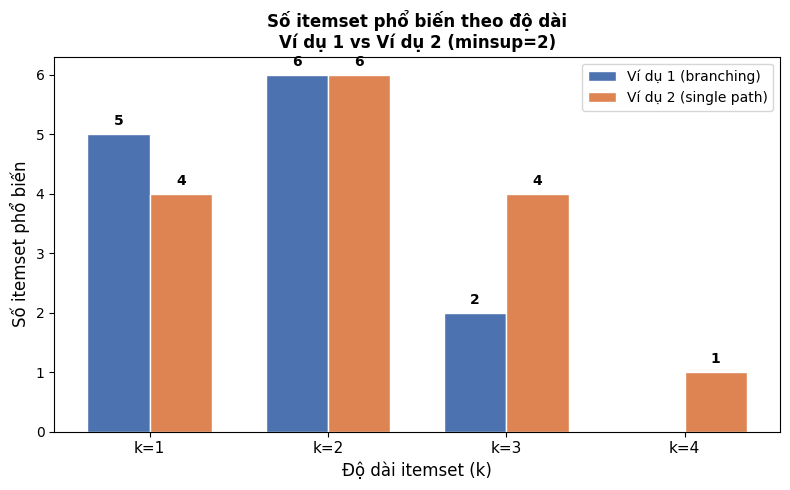

In [42]:
import matplotlib.pyplot as plt
import numpy as np

from collections import Counter
cnt1 = Counter(len(fs) for fs in frequent_itemsets_basic)
cnt2 = Counter(len(fs) for fs in frequent_itemsets_special)
max_k = max(max(cnt1), max(cnt2))
ks = list(range(1, max_k + 1))
v1 = [cnt1.get(k, 0) for k in ks]
v2 = [cnt2.get(k, 0) for k in ks]

x = np.arange(len(ks))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, v1, width, label='Ví dụ 1 (branching)', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + width/2, v2, width, label='Ví dụ 2 (single path)', color='#DD8452', edgecolor='white')
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, str(int(h)),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in ks], fontsize=11)
ax.set_xlabel('Độ dài itemset (k)', fontsize=12)
ax.set_ylabel('Số itemset phổ biến', fontsize=12)
ax.set_title('Số itemset phổ biến theo độ dài\nVí dụ 1 vs Ví dụ 2 (minsup=2)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

---
## 4. Tổng kết

| Phần | Nội dung |
|------|----------|
| PPC-tree | Xây cây prefix từ CSDL, gán số pre-order / post-order bằng DFS |
| N-list 1-itemset | Mỗi item → danh sách `(pre, post, count)` từ các nút tương ứng trên cây |
| Phép giao N-list | Hai nút giao nhau khi v là con cháu của u (điều kiện pre/post) |
| Duyệt đệ quy | Sinh itemset k+1 từ itemset k; cắt nhánh khi support < minsup |
| Cross-check | So sánh với brute-force và file expected → đảm bảo tính đúng đắn |

### So sánh PrePost với các thuật toán khác

| Tiêu chí | Apriori | FP-Growth | **PrePost** |
|----------|---------|-----------|-------------|
| Cấu trúc dữ liệu | Candidate list | FP-tree + Conditional FP-tree | PPC-tree + N-list |
| Số lần quét CSDL | Nhiều lần | 2 lần | 2 lần |
| Tính support | Duyệt CSDL | Duyệt conditional tree | **Giao N-list (số nguyên)** |
| Phù hợp | CSDL thưa, ít item | CSDL dày, bộ nhớ vừa | CSDL dày, cần tốc độ cao |

> **Điểm mạnh của PrePost:** Phép giao N-list chỉ dùng số nguyên — cache-friendly, song song hóa dễ, không cần xây lại cây con.

---
*Notebook này minh họa hoàn toàn bằng tay (không dùng thư viện khai thác ngoài).*